# 🧠 Multi-Class Classification Lab

## 🎯 Objectives
- 🔹 Understand the use of **one-hot encoding** for categorical variables.  
- 🔹 Implement **logistic regression** for multi-class classification using:  
  - **One-vs-All (OvA)**  
  - **One-vs-One (OvO)**  
- 🔹 Evaluate model performance using metrics like **accuracy, precision, recall, and F1-score**.

---

## 📊 About the Dataset
The dataset used in this lab is the **"Obesity Risk Prediction"** dataset, publicly available on the **UCI Machine Learning Repository** under the **CCA 4.0 license**.  

- 🧍 **Number of samples:** 2,111  
- 📄 **Number of attributes:** 17  
- 🎯 **Task:** Predict the **obesity level** (`NObeyesdad`) of individuals based on lifestyle, dietary habits, and physical activity.  

---

## 🗂 Attributes

| 🏷 Variable Name | 📌 Type | 📝 Description |
|-----------------|--------|----------------|
| Gender | Categorical | Gender of the individual |
| Age | Continuous | Age in years |
| Height | Continuous | Height in cm |
| Weight | Continuous | Weight in kg |
| family_history_with_overweight | Binary | Has a family member suffered or suffers from overweight? |
| FAVC | Binary | Do you eat high caloric food frequently? |
| FCVC | Integer | Do you usually eat vegetables in your meals? |
| NCP | Continuous | How many main meals do you have daily? |
| CAEC | Categorical | Do you eat any food between meals? |
| SMOKE | Binary | Do you smoke? |
| CH2O | Continuous | How much water do you drink daily? |
| SCC | Binary | Do you monitor the calories you eat daily? |
| FAF | Continuous | How often do you have physical activity? |
| TUE | Integer | Time spent using technological devices (cell phone, videogames, TV, computer, etc.) |
| CALC | Categorical | How often do you drink alcohol? |
| MTRANS | Categorical | Which transportation do you usually use? |
| NObeyesdad | Categorical | **Target variable**: Obesity level |

> ⚠️ **Note:** `NObeyesdad` is **categorical** and requires encoding for logistic regression.

---

## 🧹 Preprocessing
1. 📝 Handle missing values (if any).  
2. 🔢 Convert categorical features into numerical values using **one-hot encoding**.  
3. 🏃‍♂️ Split the dataset into **training** and **testing** sets.  
4. ⚖️ Scale numerical features if required.

---

## 🤖 Modeling
We will implement **logistic regression** using two strategies for multi-class classification:

### 1️⃣ One-vs-All (OvA)
- Train a separate binary classifier for each class.  
- Each classifier predicts whether a sample belongs to its class or not.  
- Combine predictions from all classifiers to assign the final class.

### 2️⃣ One-vs-One (OvO)
- Train a binary classifier for every pair of classes.  
- Use a **voting scheme** to decide the final class.  


In [22]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Import the dataset
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
df = pd.read_csv(url)
df.head()


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


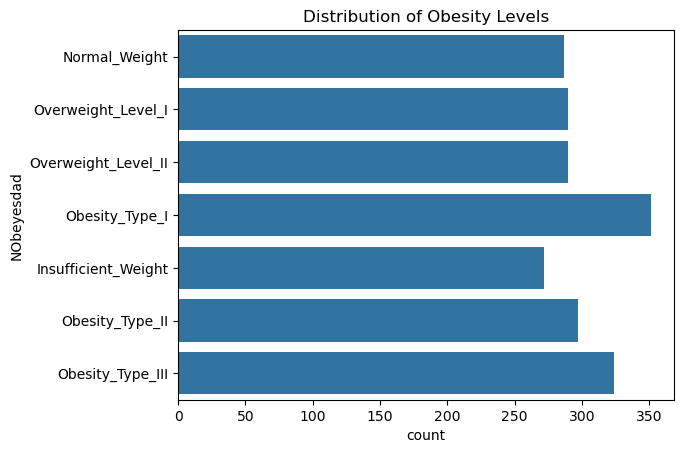

In [5]:
# Exploratory Data Analysis (EDA)
sns.countplot(y='NObeyesdad', data=df)
plt.title('Distribution of Obesity Levels')
plt.show()

This shows that the dataset is fairly balanced and does not require any special attention in terms of biased training.

In [7]:
# Checkl for null values and display summary of dataset
print(df.isnull().sum())
print(df.info())
print(df.describe())

Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height             

In [9]:
# Processing the data
# Standardizing countinuous features
countinuous_colulmns = df.select_dtypes(include=['float64']).columns.tolist()
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[countinuous_colulmns])

# Convert to DataFrame
scaled_df = pd.DataFrame(scaled_features, columns=countinuous_colulmns)

# Combine with the original DataFrame
scaled_data = pd.concat([df.drop(columns=countinuous_colulmns), scaled_df], axis=1)

In [11]:
# One-hot encoding categorical columns
# Identify categorical columns
categorical_columns = scaled_data.select_dtypes(include=['object']).columns.tolist()
categorical_columns.remove('NObeyesdad')  # Exclude target variable

# Apply one-hot encoding
encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded_features = encoder.fit_transform(scaled_data[categorical_columns])

# Convert to DataFrame
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_columns))

# Combine with the original DataFrame
prepped_data = pd.concat([scaled_data.drop(columns=categorical_columns), encoded_df], axis=1)

In [12]:
# Encoding the target variable
prepped_data['NObeyesdad'] = prepped_data['NObeyesdad'].astype('category').cat.codes
prepped_data.head()

,NObeyesdad,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,Gender_Male,...,CAEC_no,SMOKE_yes,SCC_yes,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,1,-0.522124,-0.875589,-0.862558,-0.785019,0.404153,-0.013073,-1.188039,0.561997,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,1,-0.522124,-1.947599,-1.168077,1.088342,0.404153,1.618759,2.339750,-1.080625,0.0,...,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,1,-0.206889,1.054029,-0.366090,-0.785019,0.404153,-0.013073,1.163820,0.561997,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,5,0.423582,1.054029,0.015808,1.088342,0.404153,-0.013073,1.163820,-1.080625,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,6,-0.364507,0.839627,0.122740,-0.785019,-2.167023,-0.013073,-1.188039,-1.080625,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [13]:
# Seprate the input and target data
X = prepped_data.drop(columns=['NObeyesdad'], axis=1)
y = prepped_data['NObeyesdad']

In [14]:
# Model training and evaluation
# Split the data into training and testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [15]:
# Logistic Regression with One-vs-All (OvA)
model_ova = LogisticRegression(multi_class='ovr', max_iter=1000)
model_ova.fit(X_train, y_train)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='ovr')

In [17]:
# Predict
y_pred_ova = model_ova.predict(X_test)

# Evaluate meriscs for OvA
print("One-vs-All (OvA) Strategy")
print(f"Accuracy: {np.round(100*accuracy_score(y_test, y_pred_ova),2)}")

One-vs-All (OvA) Strategy
Accuracy: 76.12


In [19]:
# Logistic Regression with Ove-vs-One (OvO)
# Train the model
model_ovo = OneVsOneClassifier(LogisticRegression(max_iter=1000))
model_ovo.fit(X_train, y_train)

OneVsOneClassifier(estimator=LogisticRegression(max_iter=1000))

In [20]:
# Predict
y_pre_ovo = model_ovo.predict(X_test)

1# Evaluate metrics for OvO
print("\nOne-vs-One (OvO) Strategy")
print(f"Accuracy: {np.round(100*accuracy_score(y_test, y_pre_ovo),2)}%")


One-vs-One (OvO) Strategy
Accuracy: 92.2%


In [ ]:
# Experement with different test sizes in the train_test_split
# Try test_size=0.3 and 0,1
for test_size in [0.1, 0.3]:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42, stratify=y)
    model_ova.fit(X_train, y_train)
    y_pred = model_ova.predict(X_test)
    print(f"Test Size: {test_size}")
    print("Accuracy:", accuracy_score(y_test, y_pred))

Test Size: 0.1
Accuracy: 0.7594339622641509
Test Size: 0.3
Accuracy: 0.749211356466877


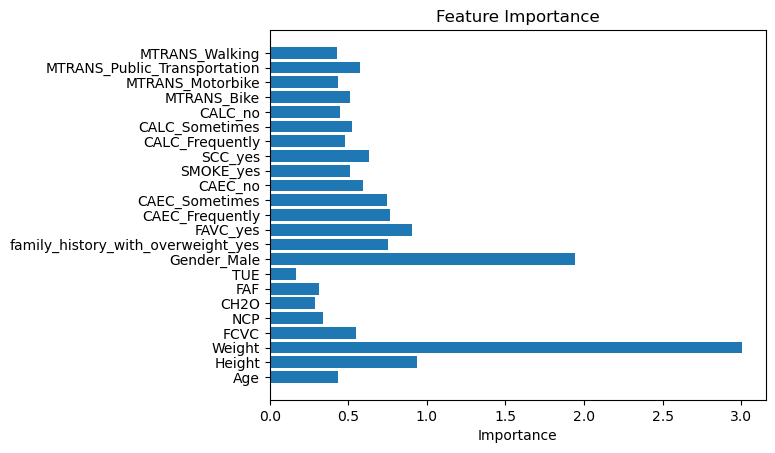

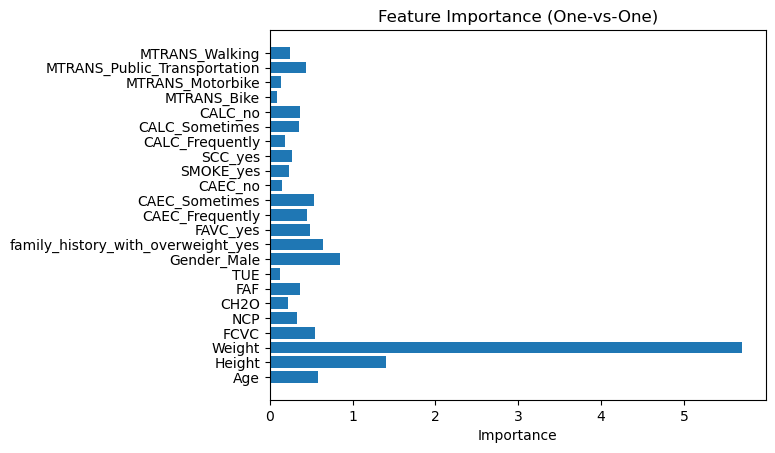

In [ ]:
# Plotting feature importance for OvA model and OvO model
# Feature importance
feature_importance = np.mean(np.abs(model_ova.coef_), axis=0)
plt.barh(X.columns, feature_importance)
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()

# For One vs One model
# Collect all coefficients from each underlying binary classifier
coefs = np.array([est.coef_[0] for est in model_ovo.estimators_])

# Now take the mean across all those classifiers
feature_importance = np.mean(np.abs(coefs), axis=0)

# Plot feature importance
plt.barh(X.columns, feature_importance)
plt.title("Feature Importance (One-vs-One)")
plt.xlabel("Importance")
plt.show()

In [39]:
# Writing a function obesity_risk_pipeline to automate the entire pipeline p
def obesity_risk_pipeline(url, test_size=0.2):
    # Import the dataset
    df = pd.read_csv(url)
    # Standardizing countinuous features
    countinuous_colulmns = df.select_dtypes(include=['float64']).columns.tolist()
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(df[countinuous_colulmns])
    # Convert to DataFrame
    scaled_df = pd.DataFrame(scaled_features, columns=scaler.get_feature_names_out(countinuous_colulmns))
    # Combine with the original DataFrame
    scaled_data = pd.concat([df.drop(columns=countinuous_colulmns), scaled_df], axis=1)
    # Identify categorical columns
    categorical_columns = scaled_data.select_dtypes(include=['object']).columns.tolist()
    categorical_columns.remove('NObeyesdad')  # Exclude target variable
    # Apply one-hot encoding
    encoder = OneHotEncoder(sparse_output=False, drop='first')
    encoded_features = encoder.fit_transform(scaled_data[categorical_columns])
    # Convert to DataFrame
    encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_columns))
    # Combine with the original DataFrame
    prepped_data = pd.concat([scaled_data.drop(columns=categorical_columns), encoded_df], axis=1)
    # Encoding the target variable
    prepped_data['NObeyesdad'] = prepped_data['NObeyesdad'].astype('category').cat.codes
    # Preparing final dataset
    X = prepped_data.drop(columns=['NObeyesdad'], axis=1)
    y = prepped_data['NObeyesdad']
    # Split the data into training and testing set
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42, stratify=y)
    # Training and evaluating the mdel
    model = LogisticRegression(multi_class='multinomial', max_iter=1000)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print("Accuracy", accuracy_score(y_test, y_pred))
# Call the pipeline function with the dataset URL
obesity_risk_pipeline(url, test_size=0.2)
   

Accuracy 0.8794326241134752
